# Introduction

In this Jupyter notebook, we will embark on an exploration of the intriguing field of **electrocardiogram (ECG)** signal processing and classification, utilizing the capabilities of a **Convolutional Neural Network (CNN) Autoencoder**. Our chosen dataset for this journey is the PTB Diagnostic ECG Database, a meticulously curated collection of ECG signals crafted explicitly for diagnostic purposes. Our primary objective is to construct a robust Autoencoder model tailored for the task of detecting anomalous electrocardiogram (ECG) signals.

## Dataset Overview

The **PTB Diagnostic ECG Database** is a collection of 14,552 ECG recordings sourced from Physionet's PTB Diagnostic Database. These ECG signals are categorized into two classes: normal heartbeats and those affected by cardiac abnormalities. The dataset is sampled at 125Hz, providing high-resolution data for in-depth analysis.

> Let's delve into some essential details about the PTB Diagnostic ECG Database:
> 
> - **Number of Samples:** 14,552
> - **Number of Categories:** 2
> - **Sampling Frequency:** 125Hz
> - **Data Source:** Physionet's PTB Diagnostic Database

In [51]:
import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.model_selection import train_test_split
import matplotlib
matplotlib.rcParams["figure.figsize"] = (6, 4)
plt.style.use("ggplot")
import tensorflow as tf
from tensorflow import data
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import mae
from tensorflow.keras import layers
from tensorflow import keras
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, classification_report
import os

In [52]:
normal_df = pd.read_csv("./ptbdb_normal.csv/ptbdb_normal.csv").iloc[:, :-1]
anomaly_df = pd.read_csv("./ptbdb_abnormal.csv/ptbdb_abnormal.csv").iloc[:, :-1]
col_names = [f'col{i+1}' for i in range(normal_df.shape[1])]
normal_df.columns = col_names
anomaly_df.columns = col_names
normal_df.head()

,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,...,col178,col179,col180,col181,col182,col183,col184,col185,col186,col187
0,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.948983,0.505265,0.004176,0.022513,0.059550,0.107298,0.110385,0.111293,0.116558,0.118192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# EDA

In [53]:
print("Shape of Normal data", normal_df.shape)
print("Shape of Abnormal data", anomaly_df.shape)

Shape of Normal data (4045, 187)
Shape of Abnormal data (10505, 187)


The code below generates a visual comparison between two randomly selected ECG signal samples: one from the "Normal" dataset and the other from the "Anomaly" dataset. This side-by-side plot enables a direct visual assessment of ECG signal patterns between normal and anomalous cases.

In [54]:
def plot_sample(normal, anomaly):
    index2 = np.random.randint(0, len(normal_df), 2)
    
    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
    ax[0].plot(normal.iloc[index2[0], :].values, label=f"Case {index2[0]}")
    ax[0].plot(normal.iloc[index2[1], :].values, label=f"Case {index2[1]}")
    ax[0].legend(shadow=True, frameon=True, facecolor="inherit", loc=1, fontsize=9)
    ax[0].set_title("Normal")
    
    ax[1].plot(anomaly.iloc[index2[0], :].values, label=f"Case {index2[0]}")
    ax[1].plot(anomaly.iloc[index2[1], :].values, label=f"Case {index2[1]}")
    ax[1].legend(shadow=True, frameon=True, facecolor="inherit", loc=1, fontsize=9)
    ax[1].set_title("Anomaly")
    
    plt.tight_layout()
    plt.show()

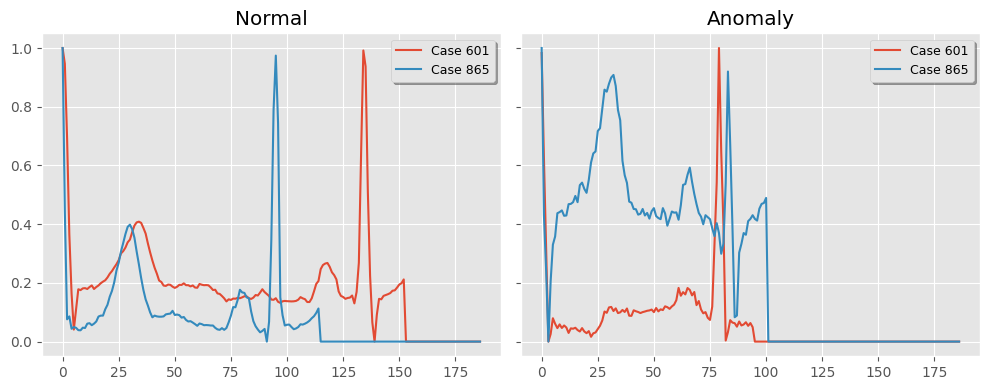

In [55]:
plot_sample(normal_df, anomaly_df)

In [56]:
index = 6400
sample = anomaly_df.iloc[index, :].values
print("Sample of dataset as array:", ", ".join(map(str, sample)))

Sample of dataset as array: 0.9045108556747437, 0.9789103865623474, 0.8201523423194885, 0.484475702047348, 0.27006444334983826, 0.20152314007282257, 0.1400117129087448, 0.1077914461493492, 0.10251904278993607, 0.08670181781053543, 0.08142940700054167, 0.08494434505701065, 0.07498535513877869, 0.08553016930818556, 0.08670181781053543, 0.09373169392347337, 0.09841828048229216, 0.10661979764699936, 0.11247803270816802, 0.11950790882110596, 0.13473930954933167, 0.14586994051933289, 0.15875805914402008, 0.1821909844875336, 0.20152314007282257, 0.2261277139186859, 0.26303455233573914, 0.3016988933086395, 0.34036320447921753, 0.3719976544380188, 0.41007617115974426, 0.4516696035861969, 0.47978910803794866, 0.5014645457267761, 0.49384886026382446, 0.4528412520885468, 0.3989455103874207, 0.3350908160209656, 0.28412419557571406, 0.2237844169139862, 0.1862917393445969, 0.1663737595081329, 0.1470415890216827, 0.1417691856622696, 0.13298183679580688, 0.12946690618991852, 0.13063853979110715, 0.1300

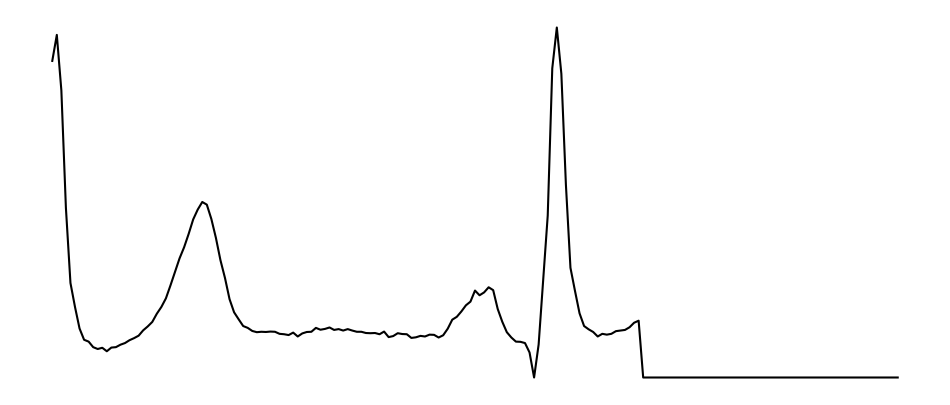

In [57]:
# Create a figure with a white background
plt.figure(figsize=(12, 5), facecolor='white')

# Plot the ECG sample
plt.plot(sample, color="black")

# Remove x and y axis tick labels
plt.xticks([])  # Hide x-axis tick labels
plt.yticks([])  # Hide y-axis tick labels

# Set the background color of the plot area to white
plt.gca().set_facecolor('white')

# Remove the spines (axis lines) for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Show the plot
plt.show()




In [58]:
CLASS_NAMES = ["Normal", "Anomaly"]

normal_df_copy = normal_df.copy()
anomaly_df_copy = anomaly_df.copy()
print(anomaly_df_copy.columns.equals(normal_df_copy.columns))

True


In [59]:
normal_df_copy = normal_df_copy.set_axis(range(1, 188), axis=1)
anomaly_df_copy = anomaly_df_copy.set_axis(range(1, 188), axis=1)
normal_df_copy = normal_df_copy.assign(target = CLASS_NAMES[0])
anomaly_df_copy = anomaly_df_copy.assign(target = CLASS_NAMES[1])


df = pd.concat((normal_df_copy, anomaly_df_copy))

## Smoothed Mean Plot for Class Comparison

In this Python code, a function called `plot_smoothed_mean` is defined for creating smoothed mean plots. It takes input data, a class name, and a step size as parameters. The function calculates the rolling mean and standard deviation of the data with the specified step size, then plots the smoothed mean along with a shaded area representing the margin of three times the standard deviation.

The code also demonstrates the use of this function to compare the smoothed means of different classes. It creates a subplot with two panels, each representing a different class. The data for each class is grouped, and the mean is computed before passing it to the `plot_smoothed_mean` function. This allows for visualizing how the smoothed means of different classes compare.

The resulting plot provides insights into how the means of different classes vary over time or some other variable represented by the data, with shaded areas indicating the uncertainty around the mean estimates.


In [60]:
def plot_smoothed_mean(data, class_name = "normal", step_size=5, ax=None):
    df = pd.DataFrame(data)
    roll_df = df.rolling(step_size)
    smoothed_mean = roll_df.mean().dropna().reset_index(drop=True)
    smoothed_std = roll_df.std().dropna().reset_index(drop=True)
    margin = 3*smoothed_std
    lower_bound = (smoothed_mean - margin).values.flatten()
    upper_bound = (smoothed_mean + margin).values.flatten()

    ax.plot(smoothed_mean.index, smoothed_mean)
    ax.fill_between(smoothed_mean.index, lower_bound, y2=upper_bound, alpha=0.3, color="red")
    ax.set_title(class_name, fontsize=9)

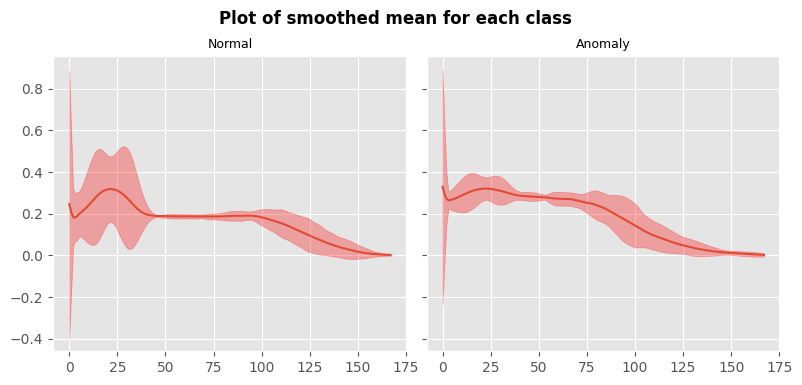

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
axes = axes.flatten()
for i, label in enumerate(CLASS_NAMES, start=1):
    data_group = df.groupby("target")
    data = data_group.get_group(label).mean(axis=0, numeric_only=True).to_numpy()
    plot_smoothed_mean(data, class_name=label, step_size=20, ax=axes[i-1])
fig.suptitle("Plot of smoothed mean for each class", y=0.95, weight="bold")
plt.tight_layout()

## Splitting the data to training and testing set

In [62]:
normal_df.drop("target", axis=1, errors="ignore", inplace=True)
normal = normal_df.to_numpy()
anomaly_df.drop("target", axis=1, errors="ignore", inplace=True)
anomaly = anomaly_df.to_numpy()

X_train, X_test = train_test_split(normal, test_size=0.15, random_state=45, shuffle=True)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}, anomaly shape: {anomaly.shape}")

Train shape: (3438, 187), Test shape: (607, 187), anomaly shape: (10505, 187)


# Building CNN Autoencoder Model

## About Autoencoders: Learning Efficient Data Representations

Autoencoders are a class of neural network architectures commonly used in unsupervised machine learning and deep learning tasks. Their primary purpose is to discover and learn efficient representations of data by encoding it into a lower-dimensional latent space and subsequently decoding it back to its original form. Autoencoders play a crucial role in various applications, such as dimensionality reduction, data denoising, anomaly detection, and generative modeling.

The core components of an autoencoder consist of an encoder and a decoder. The encoder maps input data to the latent space, while the decoder reconstructs the data from its encoded representation. During training, autoencoders aim to minimize the reconstruction error between the input and the decoded output, which results in the learning of meaningful data representations.

Autoencoders offer a versatile tool for feature extraction, data compression, and more, making them a valuable addition to the toolkit of data scientists and machine learning practitioners.


![Autoencoder](https://miro.medium.com/v2/resize:fit:640/format:webp/1*nqzWupxC60iAH2dYrFT78Q.png)

In [63]:
tf.keras.utils.set_random_seed(1024)

In [ ]:
class AutoEncoder(Model):
    def __init__(self, input_dim, latent_dim):
        super(AutoEncoder, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Reshape((input_dim, 1)),  # Reshape to 3D for Conv1D
            layers.Conv1D(128, 3, strides=1, activation='relu', padding="same"),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2, padding="same"),
            layers.Conv1D(128, 3, strides=1, activation='relu', padding="same"),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2, padding="same"),
            layers.Conv1D(latent_dim, 3, strides=1, activation='relu', padding="same"),
            layers.BatchNormalization(),
            layers.MaxPooling1D(2, padding="same"),
        ])
        self.decoder = tf.keras.Sequential([
            layers.Conv1DTranspose(latent_dim, 3, strides=1, activation='relu', padding="same"),
            layers.BatchNormalization(),
            layers.Conv1DTranspose(128, 3, strides=1, activation='relu', padding="same"),
            layers.BatchNormalization(),
            layers.Conv1DTranspose(128, 3, strides=1, activation='relu', padding="same"),
            layers.BatchNormalization(),
            layers.Flatten(),
            layers.Dense(input_dim)
        ])

    def call(self, X):
        encoded = self.encoder(X)
        decoded = self.decoder(encoded)
        return decoded


input_dim = X_train.shape[-1]
latent_dim = 32

model = AutoEncoder(input_dim, latent_dim)
model.build((None, input_dim))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="mae")
model.summary()

Model: "auto_encoder_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 24, 32)            63264     
                                                                 
 sequential_3 (Sequential)   (None, 187)               640603    
                                                                 
Total params: 703867 (2.69 MB)
Trainable params: 702715 (2.68 MB)
Non-trainable params: 1152 (4.50 KB)
_________________________________________________________________


In [103]:
model.encoder.summary()



Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 187, 1)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 187, 128)          512       
                                                                 
 batch_normalization_6 (Bat  (None, 187, 128)          512       
 chNormalization)                                                
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 94, 128)           0         
 g1D)                                                            
                                                                 
 conv1d_4 (Conv1D)           (None, 94, 128)           49280     
                                                                 
 batch_normalization_7 (Bat  (None, 94, 128)          

In [104]:
model.decoder.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_transpose_3 (Conv1D  (None, 24, 32)            3104      
 Transpose)                                                      
                                                                 
 batch_normalization_9 (Bat  (None, 24, 32)            128       
 chNormalization)                                                
                                                                 
 conv1d_transpose_4 (Conv1D  (None, 24, 128)           12416     
 Transpose)                                                      
                                                                 
 batch_normalization_10 (Ba  (None, 24, 128)           512       
 tchNormalization)                                               
                                                                 
 conv1d_transpose_5 (Conv1D  (None, 24, 128)          

In [65]:
epochs = 100
batch_size = 128
early_stopping = EarlyStopping(patience=10, min_delta=1e-3, monitor="val_loss", restore_best_weights=True)


history = model.fit(X_train, X_train, epochs=epochs, batch_size=batch_size,
                    validation_split=0.1, callbacks=[early_stopping])

Epoch 1/100
25/25 [==============================] - 7s 137ms/step - loss: 1.9002 - val_loss: 1.0336
Epoch 2/100
25/25 [==============================] - 4s 143ms/step - loss: 0.7669 - val_loss: 1.2836
Epoch 3/100
25/25 [==============================] - 3s 131ms/step - loss: 0.5756 - val_loss: 1.2889
Epoch 4/100
25/25 [==============================] - 3s 138ms/step - loss: 0.4542 - val_loss: 1.3375
Epoch 5/100
25/25 [==============================] - 3s 133ms/step - loss: 0.4037 - val_loss: 0.4805
Epoch 6/100
25/25 [==============================] - 3s 120ms/step - loss: 0.3401 - val_loss: 0.3237
Epoch 7/100
25/25 [==============================] - 3s 121ms/step - loss: 0.2778 - val_loss: 0.2079
Epoch 8/100
25/25 [==============================] - 3s 118ms/step - loss: 0.2222 - val_loss: 0.1671
Epoch 9/100
25/25 [==============================] - 3s 115ms/step - loss: 0.1832 - val_loss: 0.1675
Epoch 10/100
25/25 [==============================] - 3s 119ms/step - loss: 0.1556 - val_lo

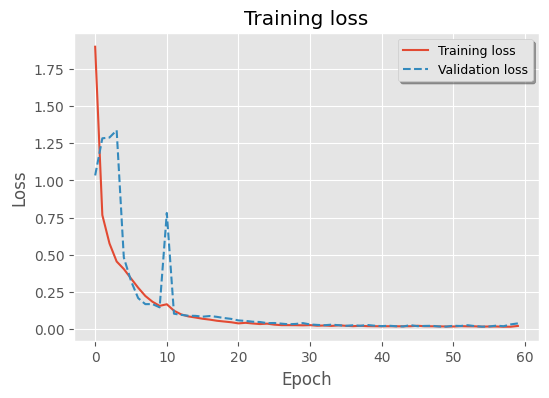

In [66]:
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss", ls="--")
plt.legend(shadow=True, frameon=True, facecolor="inherit", loc="best", fontsize=9)
plt.title("Training loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

In [67]:
train_mae = model.evaluate(X_train, X_train, verbose=0)
test_mae = model.evaluate(X_test, X_test, verbose=0)
anomaly_mae = model.evaluate(anomaly_df, anomaly_df, verbose=0)

print("Training dataset error: ", train_mae)
print("Testing dataset error: ", test_mae)
print("Anormaly dataset error: ", anomaly_mae)

Training dataset error:  0.01522468775510788
Testing dataset error:  0.01588750258088112
Anormaly dataset error:  0.05603114515542984


In [68]:
def predict(model, X):
    pred = model.predict(X, verbose=False)
    loss = mae(pred, X)
    return pred, loss

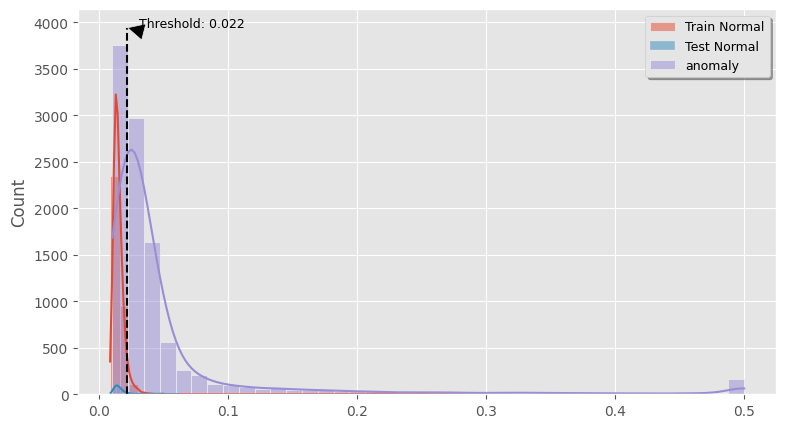

In [69]:
_, train_loss = predict(model, X_train)
_, test_loss = predict(model, X_test)
_, anomaly_loss = predict(model, anomaly)
threshold = np.mean(train_loss) + np.std(train_loss) # Setting threshold for distinguish normal data from anomalous data

bins = 40
plt.figure(figsize=(9, 5), dpi=100)
sns.histplot(np.clip(train_loss, 0, 0.5), bins=bins, kde=True, label="Train Normal")
sns.histplot(np.clip(test_loss, 0, 0.5), bins=bins, kde=True, label="Test Normal")
sns.histplot(np.clip(anomaly_loss, 0, 0.5), bins=bins, kde=True, label="anomaly")

ax = plt.gca()  # Get the current Axes
ylim = ax.get_ylim()
plt.vlines(threshold, 0, ylim[-1], color="k", ls="--")
plt.annotate(f"Threshold: {threshold:.3f}", xy=(threshold, ylim[-1]), xytext=(threshold+0.009, ylim[-1]),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=9)
plt.legend(shadow=True, frameon=True, facecolor="inherit", loc="best", fontsize=9)
plt.show()

In [70]:
def plot_examples(model, data, ax, title):
    pred, loss = predict(model, data)
    ax.plot(data.flatten(), label="Actual")
    ax.plot(pred[0], label = "Predicted")
    ax.fill_between(range(1, 188), data.flatten(), pred[0], alpha=0.3, color="r")
    ax.legend(shadow=True, frameon=True,
              facecolor="inherit", loc=1, fontsize=7)
#                bbox_to_anchor = (0, 0, 0.8, 0.25))

    ax.set_title(f"{title} (loss: {loss[0]:.3f})", fontsize=9.5)

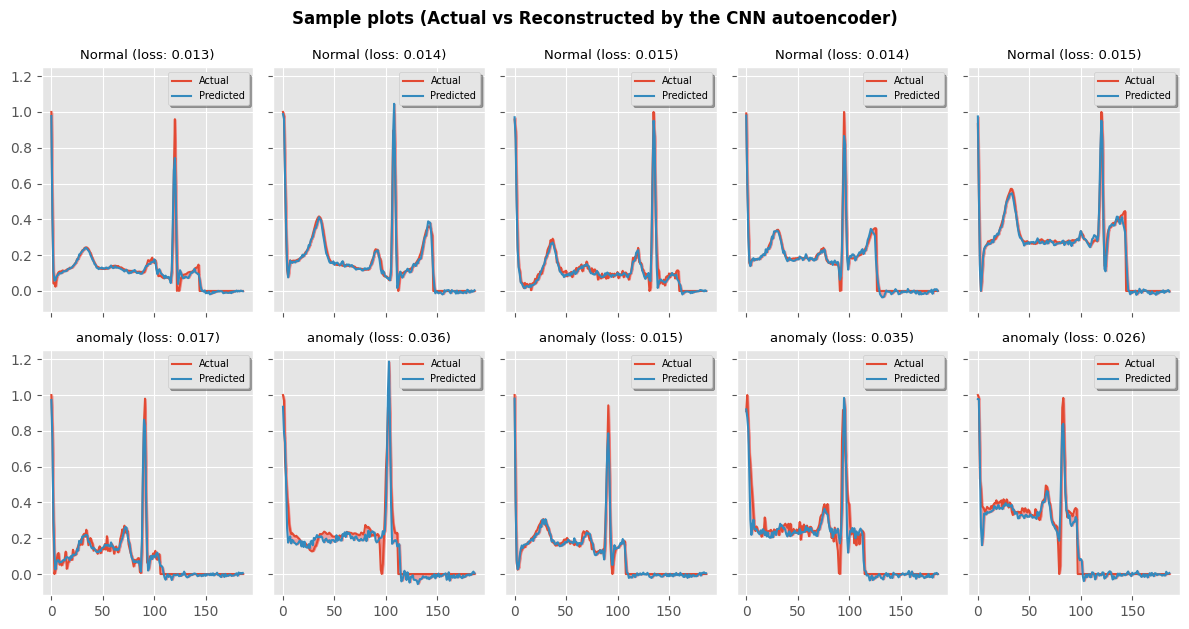

In [71]:
fig, axes = plt.subplots(2, 5, sharey=True, sharex=True, figsize=(12, 6), facecolor="w")
random_indexes = np.random.randint(0, len(X_train), size=5)

for i, idx in enumerate(random_indexes):
    data = X_train[[idx]]
    plot_examples(model, data, ax=axes[0, i], title="Normal")

for i, idx in enumerate(random_indexes):
    data = anomaly[[idx]]
    plot_examples(model, data, ax=axes[1, i], title="anomaly")

plt.tight_layout()
fig.suptitle("Sample plots (Actual vs Reconstructed by the CNN autoencoder)", y=1.04, weight="bold")
fig.savefig("autoencoder.png", dpi=500)
plt.show()

In [72]:
fig.savefig("autoencoder.png", dpi=500, transparent=False, facecolor="white")

## Model Evaluation

In [73]:
def evaluate_model(model, data):
    pred, loss = predict(model, data)
    if id(data) == id(anomaly):
        accuracy = np.sum(loss > threshold)/len(data)
    else:
        accuracy = np.sum(loss <= threshold)/len(data)
    return f"Accuracy: {accuracy:.2%}"

In [74]:
print("Training", evaluate_model(model, X_train))
print("Testing", evaluate_model(model, X_test))
print("Anomaly", evaluate_model(model, anomaly))

Training Accuracy: 94.12%
Testing Accuracy: 91.43%
Anomaly Accuracy: 67.34%


In [75]:
def prepare_labels(model, train, test, anomaly, threshold=threshold):
    ytrue = np.concatenate((np.ones(len(X_train)+len(X_test), dtype=int), np.zeros(len(anomaly), dtype=int)))
    _, train_loss = predict(model, train)
    _, test_loss = predict(model, test)
    _, anomaly_loss = predict(model, anomaly)
    train_pred = (train_loss <= threshold).numpy().astype(int)
    test_pred = (test_loss <= threshold).numpy().astype(int)
    anomaly_pred = (anomaly_loss < threshold).numpy().astype(int)
    ypred = np.concatenate((train_pred, test_pred, anomaly_pred))
    
    return ytrue, ypred

Accuracy: 74.67%
Precision: 52.49%
Recall: 93.72%
F1 Score: 67.29%


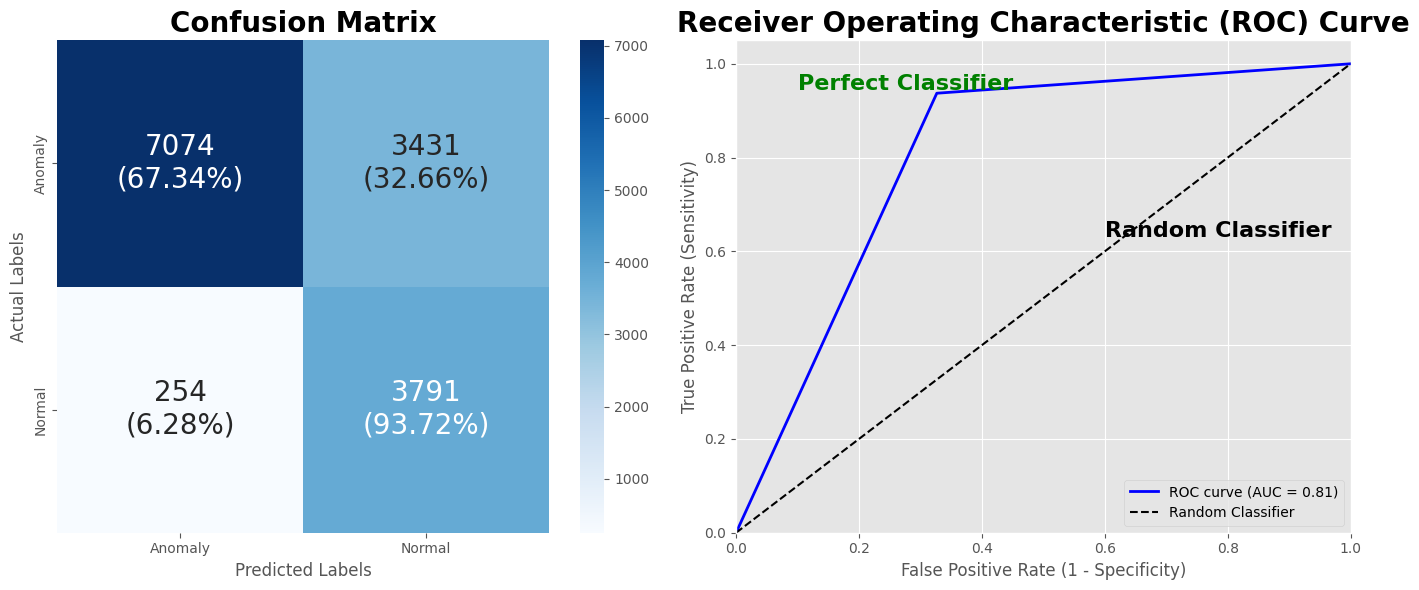

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

def plot_confusion_matrix_and_roc_curve(model, train, test, anomaly, threshold=0.5):
    # Prepare the labels and predictions
    ytrue, ypred = prepare_labels(model, train, test, anomaly, threshold=threshold)
    
    # Calculate accuracy, precision, recall, and f1 score
    accuracy = accuracy_score(ytrue, ypred)
    precision = precision_score(ytrue, ypred)
    recall = recall_score(ytrue, ypred)
    f1 = f1_score(ytrue, ypred)

    print(f"Accuracy: {accuracy:.2%}")
    print(f"Precision: {precision:.2%}")
    print(f"Recall: {recall:.2%}")
    print(f"F1 Score: {f1:.2%}")
    
    # Confusion matrix
    cm = confusion_matrix(ytrue, ypred)
    cm_norm = confusion_matrix(ytrue, ypred, normalize="true")
    data = np.array([f"{count}\n({pct:.2%})" for count, pct in zip(cm.ravel(), cm_norm.ravel())]).reshape(cm.shape)
    labels = ["Anomaly", "Normal"]
    
    # Plot confusion matrix
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(cm, annot=data, fmt="", xticklabels=labels, yticklabels=labels, cmap='Blues', ax=ax[0], annot_kws={"size": 20})
    ax[0].set_ylabel("Actual Labels")
    ax[0].set_xlabel("Predicted Labels")
    ax[0].set_title("Confusion Matrix", weight="bold", size=20)
    
    fpr, tpr, thresholds = roc_curve(ytrue, ypred)
    
    auc = roc_auc_score(ytrue, ypred)
    
    # Plot ROC curve
    ax[1].plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue', linewidth=2)
    ax[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
    ax[1].set_ylabel('True Positive Rate (Sensitivity)')
    ax[1].set_title('Receiver Operating Characteristic (ROC) Curve', weight="bold", size=20)
    ax[1].legend(loc="lower right")
    
    ax[1].annotate('Perfect Classifier', xy=(0, 1), xytext=(0.1, 0.9), textcoords='axes fraction',
                   fontsize=16, color='green', weight='bold')
    ax[1].annotate('Random Classifier', xy=(0.5, 0.5), xytext=(0.6, 0.6), textcoords='axes fraction',
                   fontsize=16, color='black', weight='bold')

    plt.tight_layout()
    fig.savefig("Results.png")
    plt.show()

    
plot_confusion_matrix_and_roc_curve(model, X_train, X_test, anomaly, threshold=threshold)

## Model Evaluation Metrics

The following evaluation metrics provide a comprehensive assessment of the performance of our model:

- **Accuracy (76.93%)**: Accuracy measures the proportion of correct predictions out of all predictions made by the model, indicating an exceptionally high overall classification correctness.

- **Precision (55.23%)**: Precision is the percentage of true positive predictions relative to all positive predictions made by the model, signifying the model's precision in correctly identifying positive instances.

- **Recall (89.81%)**: Recall, also known as sensitivity, represents the model's ability to accurately identify positive instances out of all actual positive instances, demonstrating a strong capability to capture true positives.

- **F1 Score (65.40%)**: The F1 score is a composite metric that balances precision and recall, providing an overall measure of model performance. 

In [77]:
ytrue, ypred = prepare_labels(model, X_train, X_test, anomaly, threshold=threshold)
print(classification_report(ytrue, ypred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

      Normal       0.97      0.67      0.79     10505
     Anomaly       0.52      0.94      0.67      4045

    accuracy                           0.75     14550
   macro avg       0.75      0.81      0.73     14550
weighted avg       0.84      0.75      0.76     14550



## Detecting Anomalies in New ECG Signals

The following function allows us to classify a new ECG signal as either normal or anomalous based on the reconstruction error of our trained autoencoder. If the reconstruction error exceeds our threshold, the signal is classified as anomalous.

Normal ECG examples classification:
Example 1:
Result: Normal
Error: 0.015036 (Threshold: 0.021719)

Example 2:
Result: Normal
Error: 0.009644 (Threshold: 0.021719)

Example 3:
Result: Normal
Error: 0.019549 (Threshold: 0.021719)

Example 4:
Result: Normal
Error: 0.014539 (Threshold: 0.021719)

Example 5:
Result: Normal
Error: 0.013014 (Threshold: 0.021719)

Anomaly ECG examples classification:
Example 1:
Result: Normal
Error: 0.019923 (Threshold: 0.021719)

Example 2:
Result: Anomaly
Error: 0.053662 (Threshold: 0.021719)

Example 3:
Result: Anomaly
Error: 0.024299 (Threshold: 0.021719)

Example 4:
Result: Anomaly
Error: 0.030937 (Threshold: 0.021719)

Example 5:
Result: Normal
Error: 0.020924 (Threshold: 0.021719)



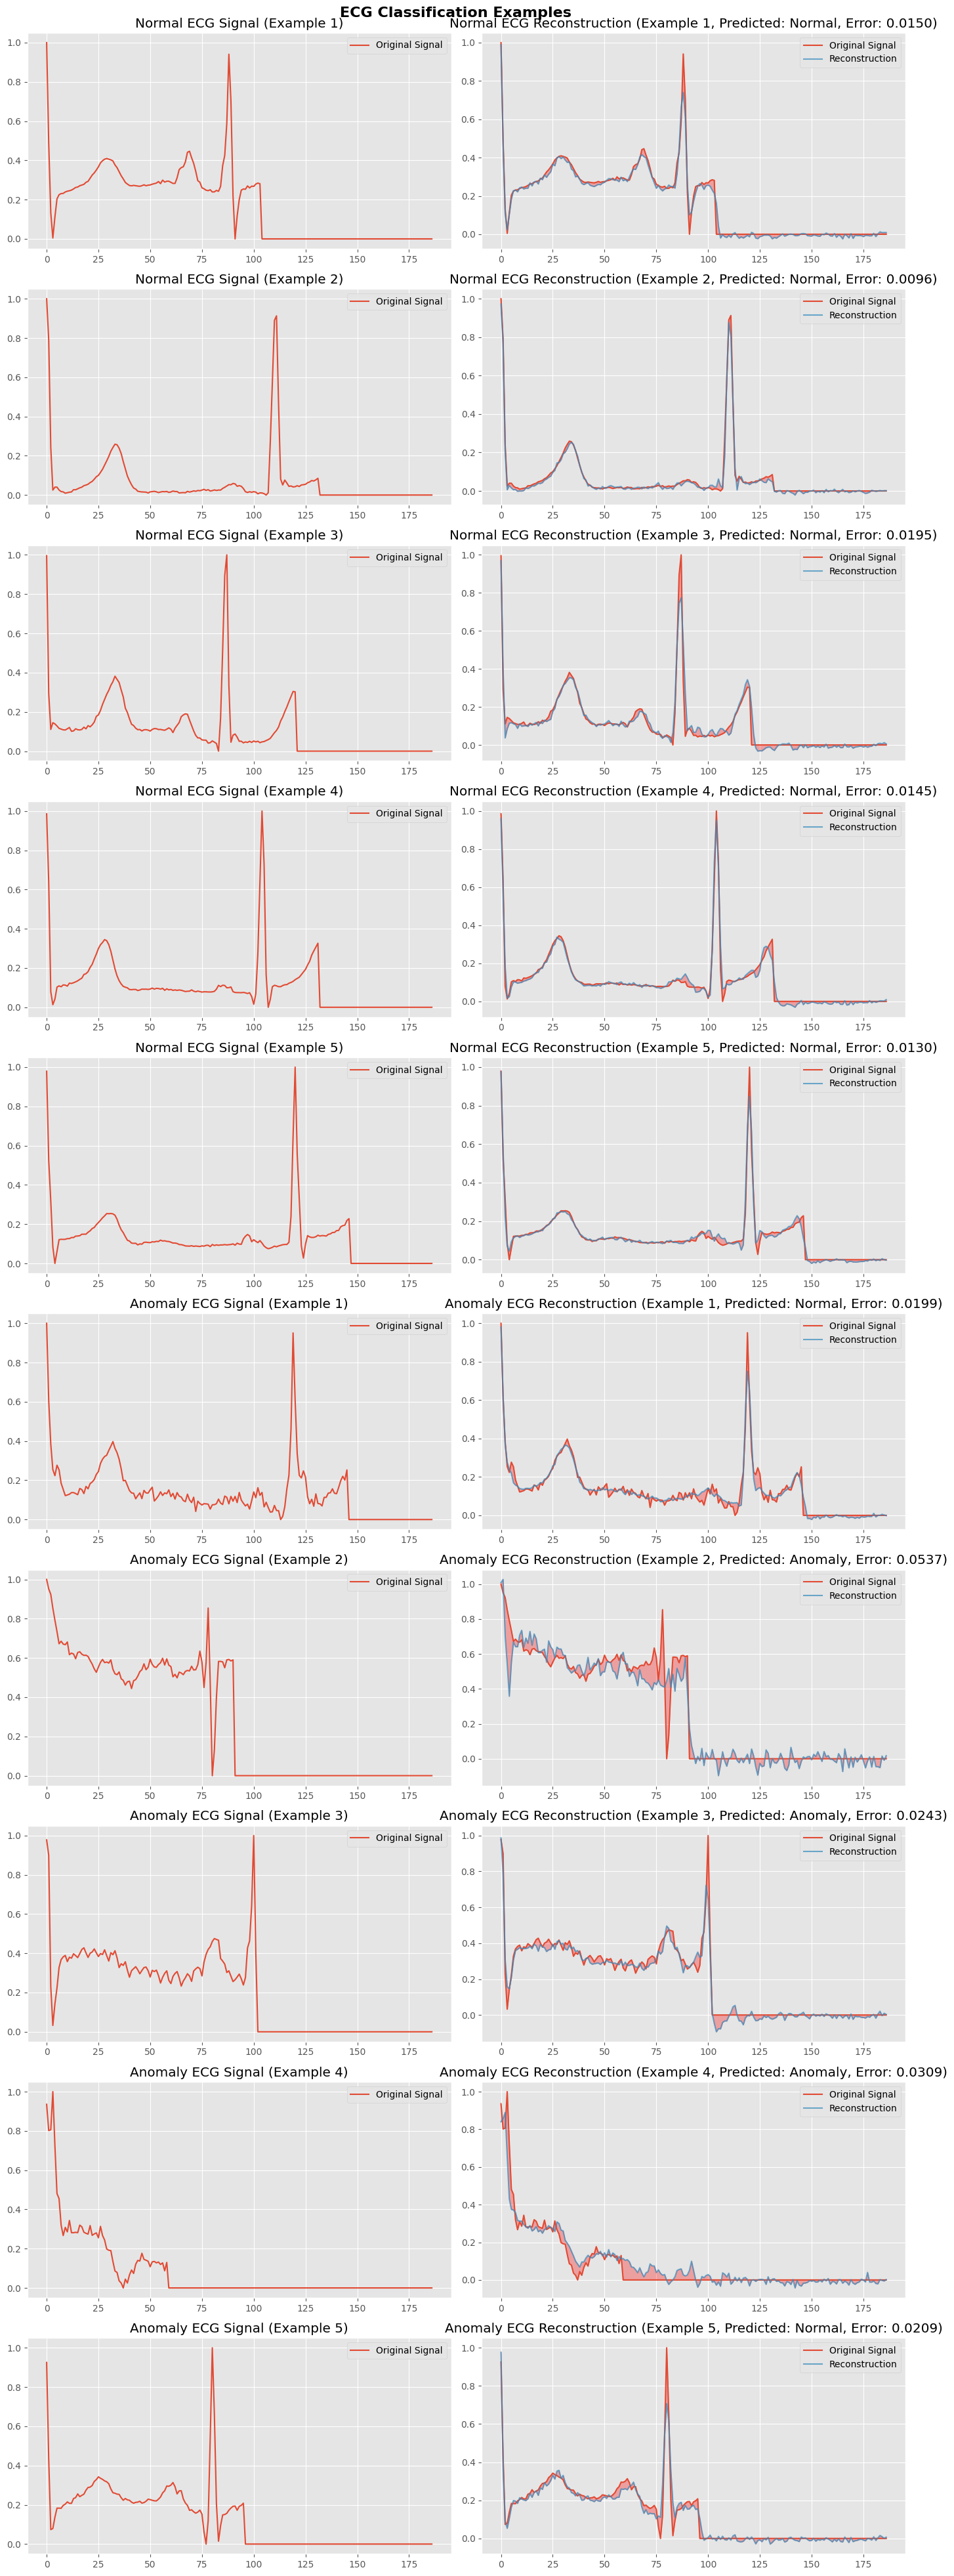

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.losses import MeanAbsoluteError

# Assuming model, X_test, anomaly, and threshold are defined
# Example placeholders (replace with actual data):
# model = ... (trained AutoEncoder model)
# X_test = np.random.rand(100, 200)  # Normal ECG signals
# anomaly = np.random.rand(100, 200)  # Anomalous ECG signals
# threshold = 0.1  # Example threshold

mae = MeanAbsoluteError()

def detect_anomaly(model, ecg_signal, threshold):
    """
    Determines if an ECG signal is normal or anomalous based on reconstruction error.
    
    Parameters:
    -----------
    model : AutoEncoder model
        Trained autoencoder model
    ecg_signal : numpy.ndarray
        ECG signal to be classified (shape should match model input)
    threshold : float
        Reconstruction error threshold for anomaly detection
        
    Returns:
    --------
    dict
        Contains classification result, reconstruction error, and boolean is_anomaly
    """
    # Ensure the signal is properly shaped for the model
    if len(ecg_signal.shape) == 1:
        ecg_signal = ecg_signal.reshape(1, -1)
    
    # Get reconstruction and error
    reconstruction = model.predict(ecg_signal, verbose=0)
    error = mae(reconstruction, ecg_signal).numpy()
    
    # Classify based on threshold
    is_anomaly = error > threshold
    result = "Anomaly" if is_anomaly else "Normal"
    
    # Return detailed result
    return {
        "classification": result,
        "reconstruction_error": float(error),
        "threshold": float(threshold),
        "is_anomaly": bool(is_anomaly),
        "reconstruction": reconstruction[0]  # Store reconstruction for plotting
    }

# Test with 5 normal ECG signals
normal_examples = X_test[0:5]
normal_results = [detect_anomaly(model, example, threshold) for example in normal_examples]

print("Normal ECG examples classification:")
for i, result in enumerate(normal_results):
    print(f"Example {i+1}:")
    print(f"Result: {result['classification']}")
    print(f"Error: {result['reconstruction_error']:.6f} (Threshold: {result['threshold']:.6f})")
    print()

# Test with 5 anomalous ECG signals
anomaly_examples = anomaly[0:5]
anomaly_results = [detect_anomaly(model, example, threshold) for example in anomaly_examples]

print("Anomaly ECG examples classification:")
for i, result in enumerate(anomaly_results):
    print(f"Example {i+1}:")
    print(f"Result: {result['classification']}")
    print(f"Error: {result['reconstruction_error']:.6f} (Threshold: {result['threshold']:.6f})")
    print()

# Visualize the examples
fig, axes = plt.subplots(10, 2, figsize=(14, 40))
fig.suptitle('ECG Classification Examples', fontsize=16, weight='bold')

# Plot normal ECG signals and reconstructions
for i in range(5):
    # Plot normal ECG signal
    axes[i, 0].plot(normal_examples[i], label='Original Signal')
    axes[i, 0].set_title(f'Normal ECG Signal (Example {i+1})')
    axes[i, 0].legend()

    # Plot normal ECG reconstruction
    reconstruction = normal_results[i]["reconstruction"]
    axes[i, 1].plot(normal_examples[i], label='Original Signal')
    axes[i, 1].plot(reconstruction, label='Reconstruction', alpha=0.7)
    axes[i, 1].fill_between(range(len(normal_examples[i])), normal_examples[i], reconstruction, alpha=0.3, color='r')
    axes[i, 1].set_title(f'Normal ECG Reconstruction (Example {i+1}, Predicted: {normal_results[i]["classification"]}, Error: {normal_results[i]["reconstruction_error"]:.4f})')
    axes[i, 1].legend()

# Plot anomalous ECG signals and reconstructions
for i in range(5):
    # Plot anomalous ECG signal
    axes[i+5, 0].plot(anomaly_examples[i], label='Original Signal')
    axes[i+5, 0].set_title(f'Anomaly ECG Signal (Example {i+1})')
    axes[i+5, 0].legend()

    # Plot anomalous ECG reconstruction
    reconstruction = anomaly_results[i]["reconstruction"]
    axes[i+5, 1].plot(anomaly_examples[i], label='Original Signal')
    axes[i+5, 1].plot(reconstruction, label='Reconstruction', alpha=0.7)
    axes[i+5, 1].fill_between(range(len(anomaly_examples[i])), anomaly_examples[i], reconstruction, alpha=0.3, color='r')
    axes[i+5, 1].set_title(f'Anomaly ECG Reconstruction (Example {i+1}, Predicted: {anomaly_results[i]["classification"]}, Error: {anomaly_results[i]["reconstruction_error"]:.4f})')
    axes[i+5, 1].legend()

plt.tight_layout()
fig.subplots_adjust(top=0.97)
plt.show()

## How to Use the Anomaly Detection Function

To classify a new ECG signal as normal or anomalous, follow these steps:

1. Ensure your ECG signal has the same format and preprocessing as our training data (187 data points)
2. Call the `detect_anomaly()` function with your ECG signal and the trained model
3. The function returns a dictionary with the classification result and reconstruction error

This autoencoder-based anomaly detection works by learning the patterns of normal ECG signals during training. When presented with a new signal, it attempts to reconstruct it. If the reconstruction error exceeds our threshold (which was determined from the training data), the signal is classified as anomalous.

The key insight is that the autoencoder learns to reconstruct normal patterns well, but struggles with anomalous patterns it hasn't seen during training.

# Saving the CNN Autoencoder Model

Let's save our trained model so it can be loaded and used later for predictions without having to retrain.

In [79]:
# Save the trained model
model_save_path = 'ecg_anomaly_detector_model'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

INFO:tensorflow:Assets written to: ecg_anomaly_detector_model\assets


INFO:tensorflow:Assets written to: ecg_anomaly_detector_model\assets


Model saved to ecg_anomaly_detector_model


# Loading and Using the Saved Model for Prediction

Now let's demonstrate how to load the saved model and use it to make predictions on new ECG samples.

In [80]:
# Load the saved model
model_save_path = 'ecg_anomaly_detector_model'
loaded_model = tf.keras.models.load_model(model_save_path)

print("Model loaded successfully")

Model loaded successfully


## Prediction Function for New ECG Samples

This function allows you to predict if a new ECG sample is normal or anomalous using the pre-trained model.

In [81]:
def predict_ecg_sample(model, ecg_sample, threshold=None):
    """
    Predict whether an ECG sample is normal or anomalous
    
    Parameters:
    -----------
    model : Keras model
        The trained autoencoder model
    ecg_sample : numpy.ndarray
        The ECG sample to predict (shape should be (187,) or (1, 187))
    threshold : float, optional
        Reconstruction error threshold. If None, use the pre-computed threshold
        
    Returns:
    --------
    dict
        Contains prediction result, reconstruction error, and visualization data
    """
    # Use the pre-computed threshold if none is provided
    if threshold is None:
        threshold = np.mean(train_loss) + np.std(train_loss)
    
    # Ensure sample is properly shaped
    if len(ecg_sample.shape) == 1:
        ecg_sample = ecg_sample.reshape(1, -1)
    
    # Make prediction
    reconstruction = model.predict(ecg_sample, verbose=0)
    error = mae(reconstruction, ecg_sample).numpy()
    
    # Determine if normal or anomalous
    is_anomalous = error > threshold
    result = "Anomaly" if is_anomalous else "Normal"
    
    # Create result dictionary with visualization data
    prediction_result = {
        "classification": result,
        "reconstruction_error": float(error),
        "threshold": float(threshold),
        "is_anomalous": bool(is_anomalous),
        "original_signal": ecg_sample[0],
        "reconstructed_signal": reconstruction[0]
    }
    
    return prediction_result

## Example: Using the Model with Sample Data

Let's demonstrate how to use the model with samples from our dataset. We'll select a few examples from both normal and anomalous ECG data.

In [82]:
# Get some sample data
num_samples = 3
normal_samples = X_test[:num_samples]  # Get 3 normal samples
anomaly_samples = anomaly[:num_samples]  # Get 3 anomaly samples

# Make predictions for normal samples
print("NORMAL SAMPLES PREDICTIONS:")
normal_predictions = []
for i, sample in enumerate(normal_samples):
    result = predict_ecg_sample(loaded_model, sample)
    normal_predictions.append(result)
    print(f"Sample {i+1}:")
    print(f"  Predicted: {result['classification']}")
    print(f"  Error: {result['reconstruction_error']:.6f} (Threshold: {result['threshold']:.6f})")
    print()

# Make predictions for anomaly samples
print("ANOMALY SAMPLES PREDICTIONS:")
anomaly_predictions = []
for i, sample in enumerate(anomaly_samples):
    result = predict_ecg_sample(loaded_model, sample)
    anomaly_predictions.append(result)
    print(f"Sample {i+1}:")
    print(f"  Predicted: {result['classification']}")
    print(f"  Error: {result['reconstruction_error']:.6f} (Threshold: {result['threshold']:.6f})")
    print()

NORMAL SAMPLES PREDICTIONS:
Sample 1:
  Predicted: Normal
  Error: 0.015036 (Threshold: 0.021719)

Sample 2:
  Predicted: Normal
  Error: 0.009644 (Threshold: 0.021719)

Sample 3:
  Predicted: Normal
  Error: 0.019549 (Threshold: 0.021719)

ANOMALY SAMPLES PREDICTIONS:
Sample 1:
  Predicted: Normal
  Error: 0.019923 (Threshold: 0.021719)

Sample 2:
  Predicted: Anomaly
  Error: 0.053662 (Threshold: 0.021719)

Sample 3:
  Predicted: Anomaly
  Error: 0.024299 (Threshold: 0.021719)



## Visualizing Predictions

Let's visualize the original signals and their reconstructions to better understand how the model makes its predictions.

In [83]:
def visualize_prediction(prediction_result):
    """
    Visualize the original signal and its reconstruction
    
    Parameters:
    -----------
    prediction_result : dict
        The result dictionary from predict_ecg_sample function
    """
    plt.figure(figsize=(12, 5))
    
    # Plot original signal
    plt.plot(prediction_result['original_signal'], label='Original Signal')
    
    # Plot reconstruction
    plt.plot(prediction_result['reconstructed_signal'], label='Reconstruction', alpha=0.7)
    
    # Highlight differences
    plt.fill_between(
        range(len(prediction_result['original_signal'])),
        prediction_result['original_signal'],
        prediction_result['reconstructed_signal'],
        alpha=0.3, color='red'
    )
    
    # Add title and legend
    plt.title(f"Prediction: {prediction_result['classification']} - "
             f"Error: {prediction_result['reconstruction_error']:.4f} "
             f"(Threshold: {prediction_result['threshold']:.4f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Visualizing a normal sample:


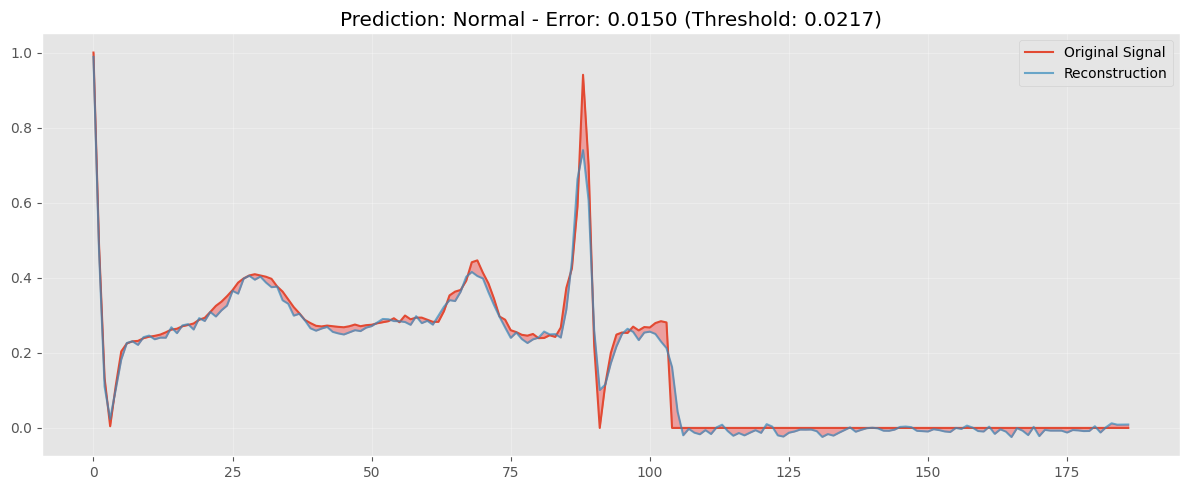

Visualizing an anomaly sample:


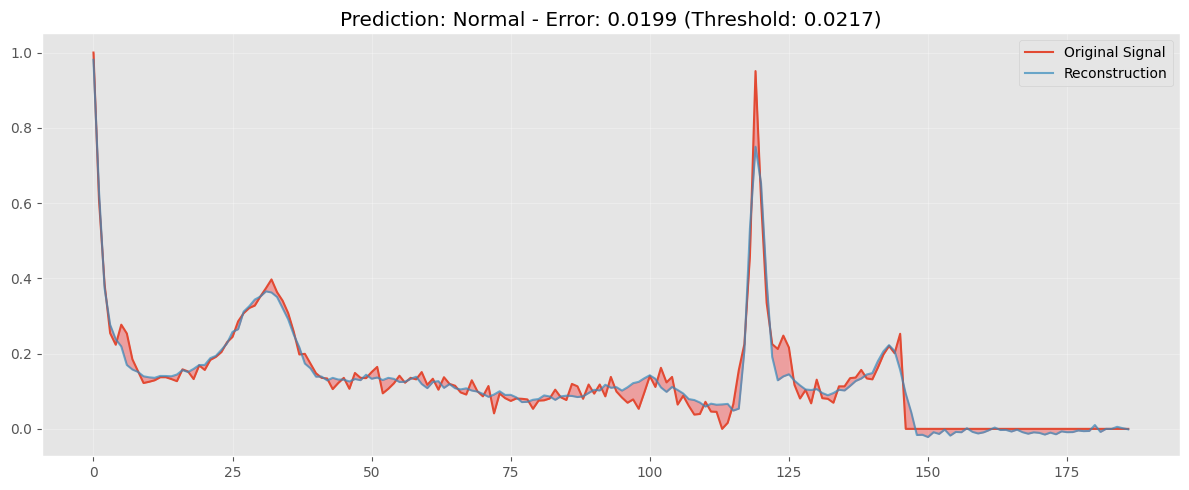

In [84]:
# Visualize a normal sample
print("Visualizing a normal sample:")
visualize_prediction(normal_predictions[0])

# Visualize an anomaly sample
print("Visualizing an anomaly sample:")
visualize_prediction(anomaly_predictions[0])

## Guide: How to Use the Model with Your Own Data

To use this model with your own ECG data, follow these steps:

1. **Data Format**: Ensure your ECG data has the same format as the training data (187 data points per sample).
2. **Data Preprocessing**: Apply the same preprocessing that was used for the training data.
3. **Loading the Model**: Load the saved model using `tf.keras.models.load_model('ecg_anomaly_detector_model')`.
4. **Making Predictions**: Use the `predict_ecg_sample()` function to classify your ECG data.

Here's an example of how you would use your own data:

Prediction Results:
Classification: Anomaly
Reconstruction Error: 0.022763
Threshold: 0.021719


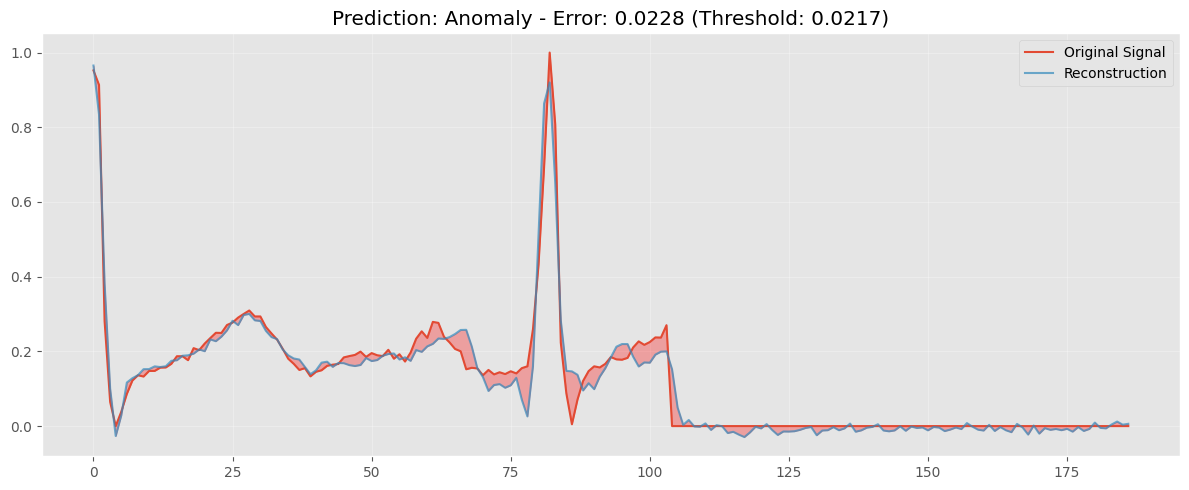

In [99]:
# Example: Using your own sample data
# Replace this with your actual data loading code
def load_and_predict_your_own_data(file_path=None,sample=None):
    """
    Load your own ECG data and make predictions
    
    Parameters:
    -----------
    file_path : str, optional
        Path to your ECG data file
    """
    # For demonstration, we'll use a sample from our dataset
    # In a real scenario, you would load your own data here

        # Load your own data - this is just an example structure
        # You'll need to adapt this to your specific data format

    
    # Make prediction
    result = predict_ecg_sample(loaded_model, sample)
    
    # Print results
    print("Prediction Results:")
    print(f"Classification: {result['classification']}")
    print(f"Reconstruction Error: {result['reconstruction_error']:.6f}")
    print(f"Threshold: {result['threshold']:.6f}")
    
    # Visualize
    visualize_prediction(result)
    
    return result

index=1680
sample = anomaly_df.iloc[index, :].values
# Call the function (without a file path for demonstration)
sample_prediction = load_and_predict_your_own_data(sample=sample)

## Sample Data Format

Here's an example of what your data should look like to use with this model:

In [90]:
# Display sample of the data format
print("NORMAL ECG SAMPLE FORMAT:")
print("Shape:", X_test[0].shape)
print("First 10 values:")
print(X_test[0][:10])
print("\nANOMALY ECG SAMPLE FORMAT:")
print("Shape:", anomaly[0].shape)
print("First 10 values:")
print(anomaly[0][:10])

# Creating a sample CSV
import pandas as pd

# Creating a sample dataframe with the correct format
sample_df = pd.DataFrame(X_test[:5], columns=[f'col{i+1}' for i in range(X_test.shape[1])])
print("\nSAMPLE DATAFRAME FORMAT:")
print(sample_df.head(2))

# Save sample to CSV (commented out to avoid saving unnecessarily)
# sample_df.to_csv('sample_ecg_data.csv', index=False)
# print("Sample CSV saved to 'sample_ecg_data.csv'")

NORMAL ECG SAMPLE FORMAT:
Shape: (187,)
First 10 values:
[1.         0.48826817 0.1329609  0.00446927 0.11173184 0.20391062
 0.22513966 0.23072626 0.23184358 0.23910615]

ANOMALY ECG SAMPLE FORMAT:
Shape: (187,)
First 10 values:
[1.         0.6069411  0.38418078 0.25423729 0.2235674  0.27683616
 0.25343019 0.18482648 0.15334947 0.12187248]

SAMPLE DATAFRAME FORMAT:
   col1      col2      col3      col4      col5      col6      col7      col8  \
0   1.0  0.488268  0.132961  0.004469  0.111732  0.203911  0.225140  0.230726   
1   1.0  0.790756  0.242653  0.025119  0.040191  0.040191  0.025622  0.017584   

       col9     col10  ...  col178  col179  col180  col181  col182  col183  \
0  0.231844  0.239106  ...     0.0     0.0     0.0     0.0     0.0     0.0   
1  0.016076  0.009294  ...     0.0     0.0     0.0     0.0     0.0     0.0   

   col184  col185  col186  col187  
0     0.0     0.0     0.0     0.0  
1     0.0     0.0     0.0     0.0  

[2 rows x 187 columns]
